In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/master_dataset.csv")

print(df.shape)
print(df.head())

(282, 10)
         Date   CPI       GDP  Unemployment   RSI  Bank_Rate      FTSE100  \
0  2001-07-01  73.7  497938.0           5.1  73.9       5.25  5546.899902   
1  2001-08-01  73.9  497938.0           5.1  74.1       5.00  5345.000000   
2  2001-09-01  74.1  497938.0           5.1  74.5       4.75  4785.600098   
3  2001-10-01  73.9  499278.0           5.1  75.0       4.50  5039.700195   
4  2001-11-01  73.8  499278.0           5.2  76.0       4.00  5203.600098   

   Inflation_YoY  Inflation_lag3  Inflation_lag6  
0       1.515152        1.307639        1.061375  
1       1.931034        1.648352        0.692521  
2       1.367989        1.646091        0.968188  
3       1.025290        1.515152        1.307639  
4       0.819672        1.931034        1.648352  


## Calculating Inflation YoY

In [3]:
df["Inflation_YoY"] = df["CPI"].pct_change(12) * 100
df = df.dropna()

print(df.head())

          Date    CPI       GDP  Unemployment   RSI  Bank_Rate      FTSE100  \
12  2002-07-01  74.50  506386.0           5.2  78.5        4.0  4044.500000   
13  2002-08-01  74.60  506386.0           5.3  78.2        4.0  4227.299805   
14  2002-09-01  74.80  506386.0           5.2  78.6        4.0  3797.399902   
15  2002-10-01  74.95  509728.0           5.2  78.9        4.0  4039.699951   
16  2002-11-01  74.90  509728.0           5.1  79.5        4.0  4169.399902   

    Inflation_YoY  Inflation_lag3  Inflation_lag6  
12       1.085482        1.154891        1.415525  
13       0.947226        0.810811        1.513067  
14       0.944669        0.674764        1.506849  
15       1.420839        1.085482        1.154891  
16       1.490515        0.947226        0.810811  


In [4]:
df.describe()

,CPI,GDP,Unemployment,RSI,Bank_Rate,FTSE100,Inflation_YoY,Inflation_lag3,Inflation_lag6
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,97.964753,602977.455556,5.458889,91.977778,2.089537,6198.844074,2.689860,2.671854,2.665740
std,16.475764,55114.673984,1.415151,8.727197,2.052429,1143.922681,2.134680,2.143125,2.145569
min,74.500000,506386.000000,3.600000,78.000000,0.175000,3567.399902,-0.099900,-0.099900,-0.099900
25%,83.350000,560675.000000,4.300000,85.200000,0.500000,5478.250122,1.491718,1.451195,1.437755
50%,99.150000,587383.000000,5.100000,87.650000,0.500000,6290.099853,2.294932,2.269697,2.260261
75%,107.850000,657225.000000,6.175000,100.000000,4.500000,7139.124878,3.050203,3.050203,3.050203
max,135.600000,698780.000000,8.500000,112.600000,5.750000,8376.599609,10.921053,10.921053,10.921053


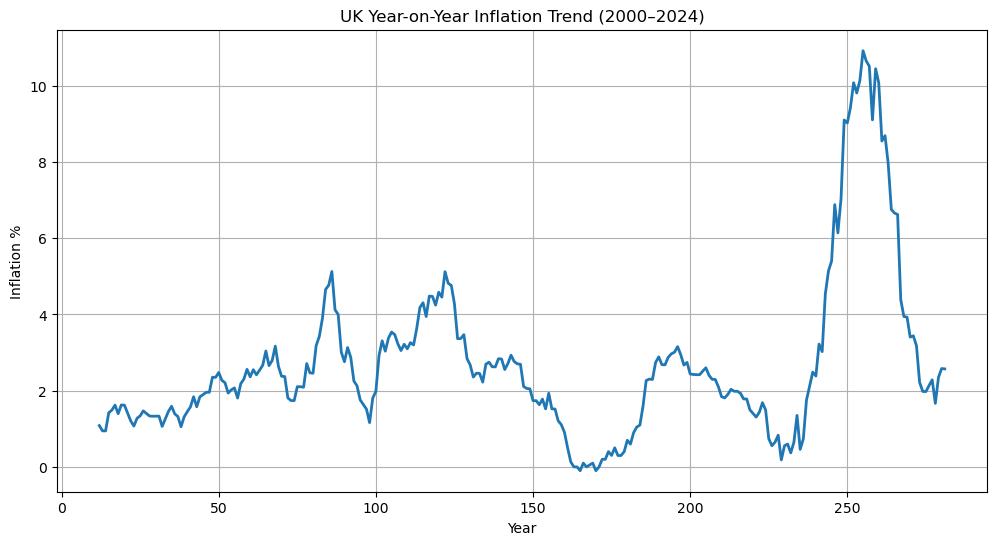

In [5]:

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Inflation_YoY"], linewidth=2)

plt.title("UK Year-on-Year Inflation Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Inflation %")

plt.grid(True)

plt.show()

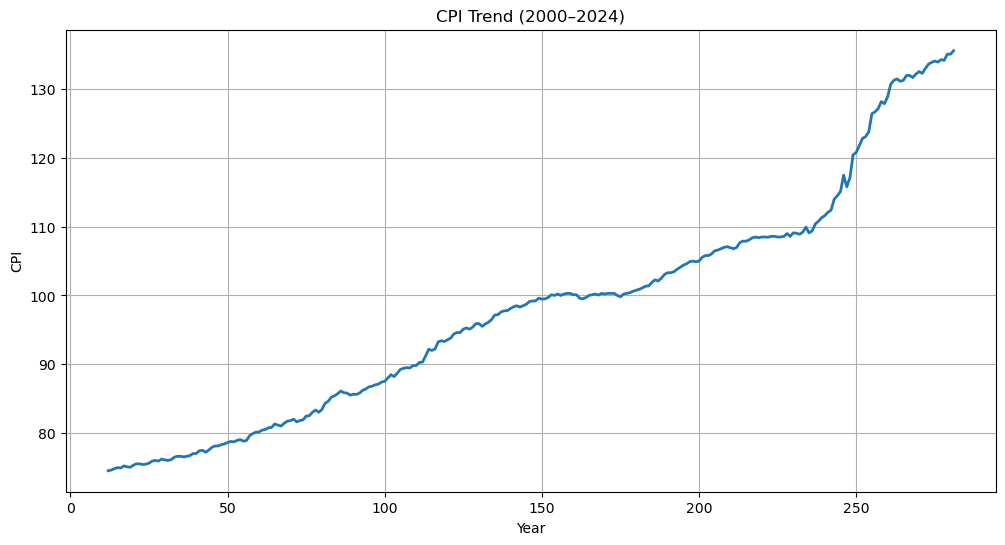

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["CPI"], linewidth=2)

plt.title("CPI Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("CPI")

plt.grid(True)

plt.show()

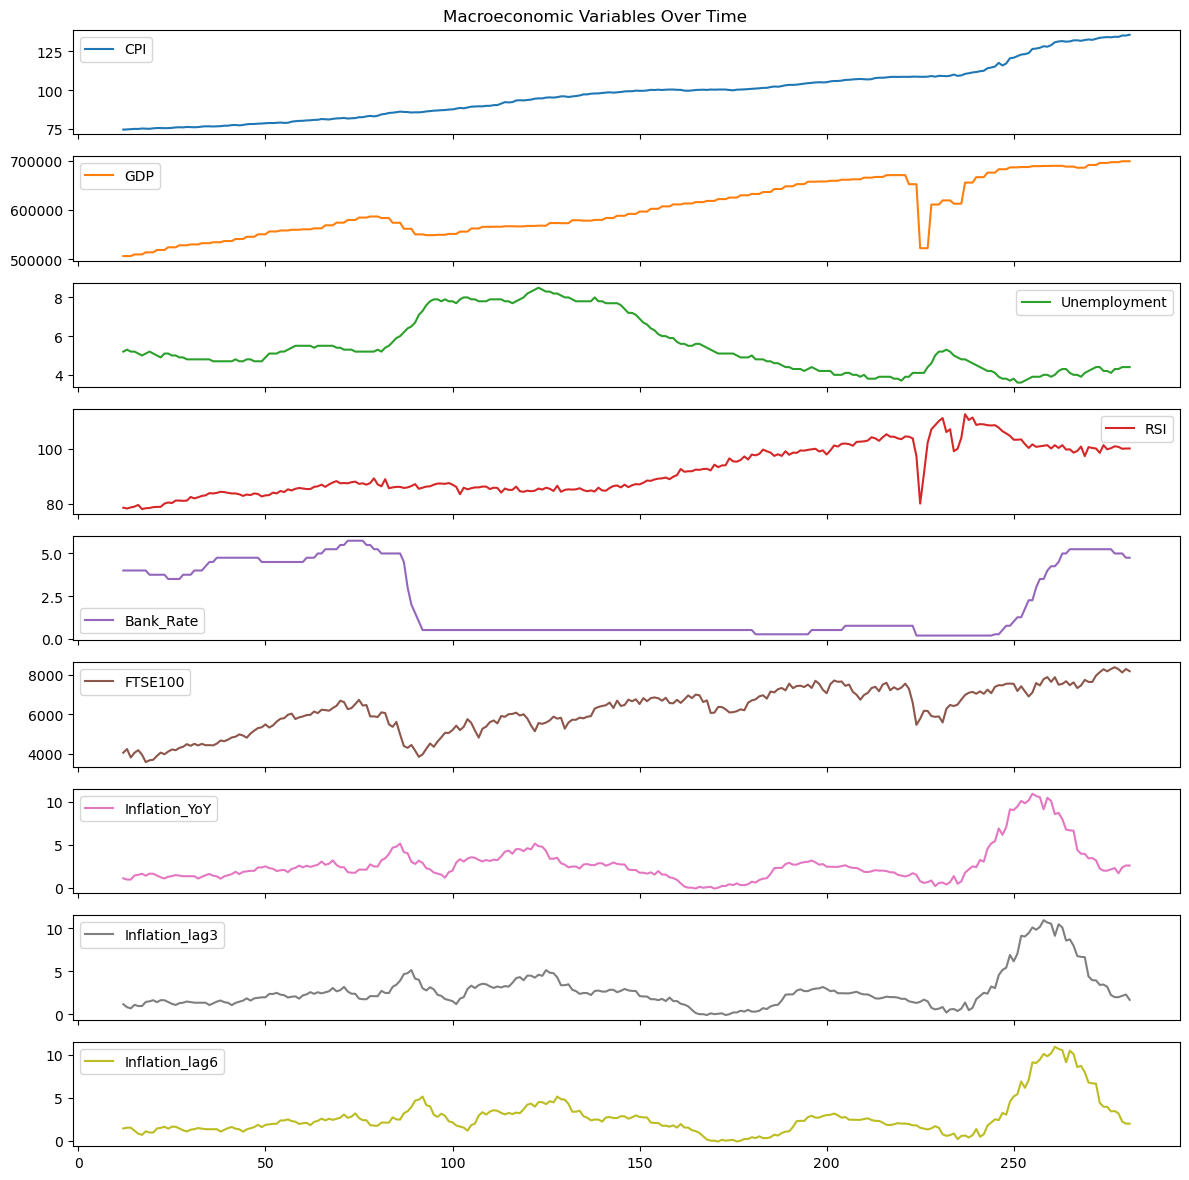

In [7]:
df.plot(subplots=True, figsize=(12,12), title="Macroeconomic Variables Over Time")
plt.tight_layout()
plt.show()

Correlation Matrix

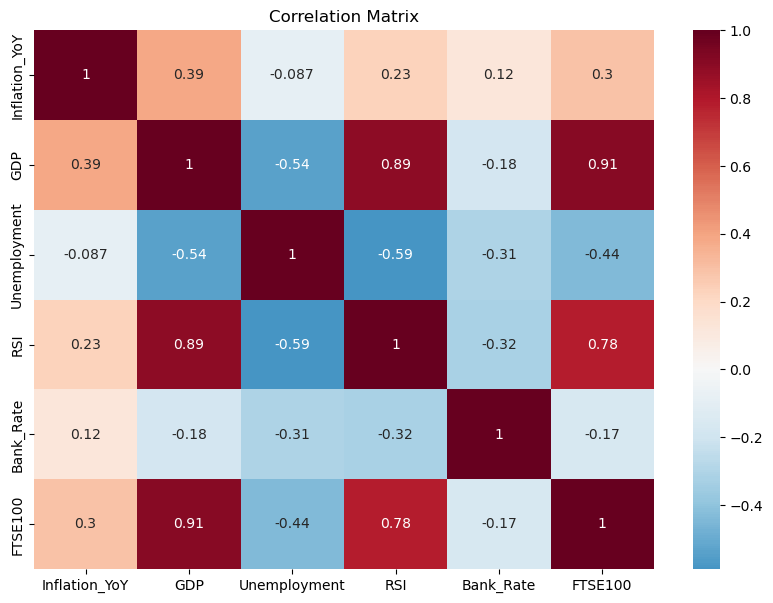

In [8]:
corr_cols = [
    "Inflation_YoY",
    "GDP",
    "Unemployment",
    "RSI",
    "Bank_Rate",
    "FTSE100"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

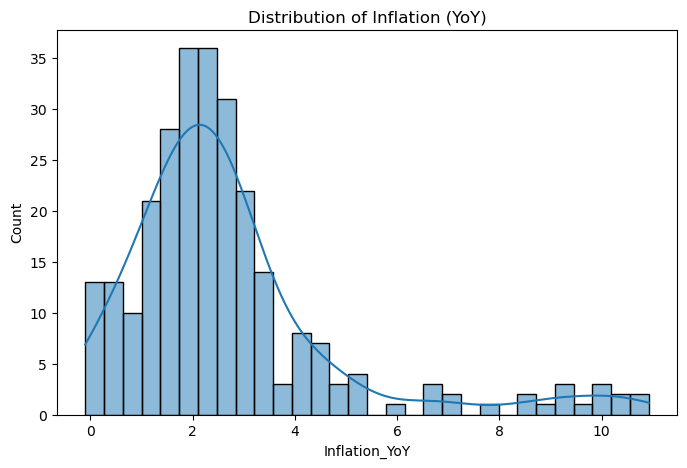

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Inflation_YoY"], bins=30, kde=True)

plt.title("Distribution of Inflation (YoY)")

plt.show()

ADF Stationarity Tests

In [10]:
def adf_test(series, name):

    result = adfuller(series)

    print(f"ADF Test: {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("--------------------------")

In [11]:
adf_test(df["CPI"], "CPI")
adf_test(df["Inflation_YoY"], "Inflation YoY")
adf_test(df["GDP"], "GDP")
adf_test(df["Unemployment"], "Unemployment")
adf_test(df["Bank_Rate"], "Bank Rate")

ADF Test: CPI
ADF Statistic: 1.5953106015399163
p-value: 0.9978434387452889
--------------------------
ADF Test: Inflation YoY
ADF Statistic: -2.9293955172510153
p-value: 0.04203493093594298
--------------------------
ADF Test: GDP
ADF Statistic: -1.197508827969007
p-value: 0.6746664320901957
--------------------------
ADF Test: Unemployment
ADF Statistic: -1.0937545097145642
p-value: 0.7175560970923661
--------------------------
ADF Test: Bank Rate
ADF Statistic: -1.7961796564096393
p-value: 0.3823600309750815
--------------------------


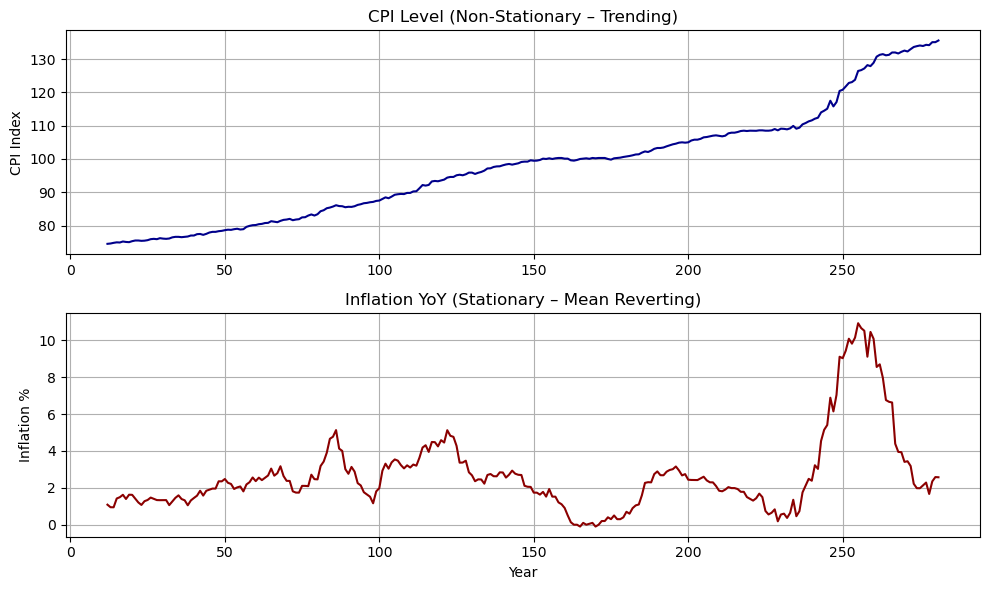

In [12]:
plt.figure(figsize=(10,6))

# CPI level (non-stationary)
plt.subplot(2,1,1)
plt.plot(df.index, df["CPI"], color="darkblue")
plt.title("CPI Level (Non-Stationary – Trending)")
plt.ylabel("CPI Index")
plt.grid(True)

# Inflation YoY (stationary)
plt.subplot(2,1,2)
plt.plot(df.index, df["Inflation_YoY"], color="darkred")
plt.title("Inflation YoY (Stationary – Mean Reverting)")
plt.ylabel("Inflation %")
plt.xlabel("Year")
plt.grid(True)

plt.tight_layout()
plt.show()

Distribution Analysis for Each Variable

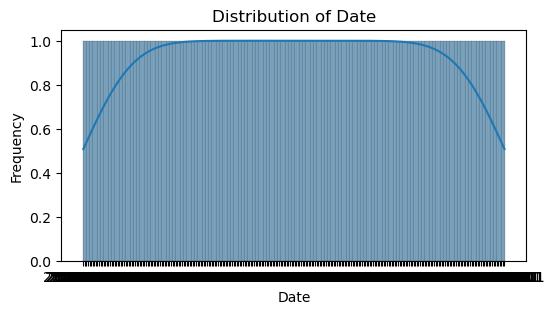

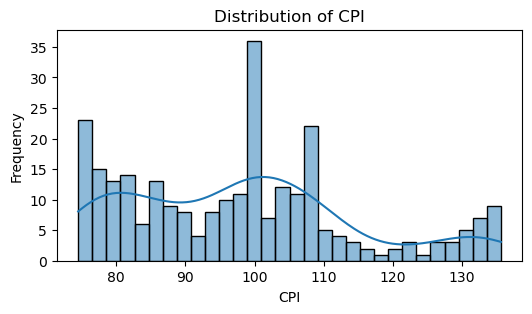

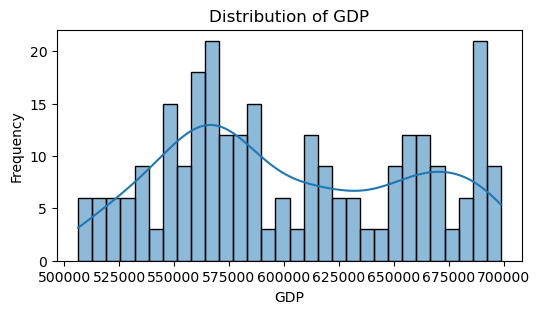

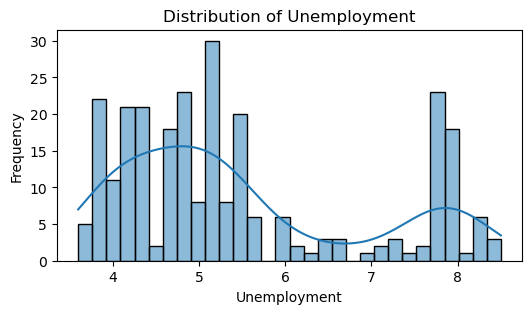

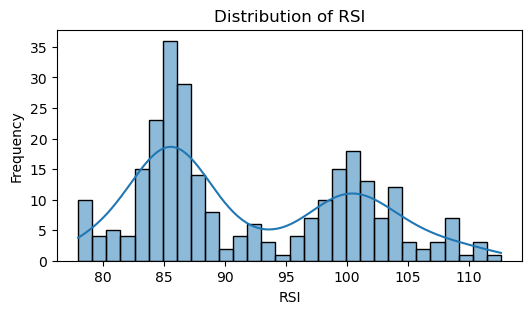

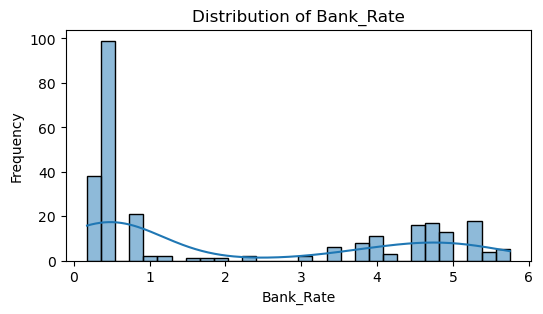

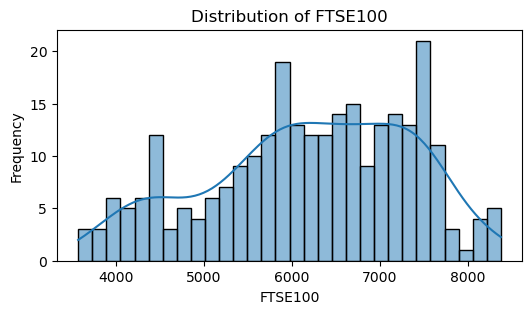

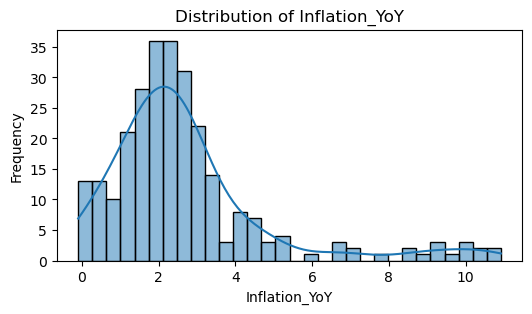

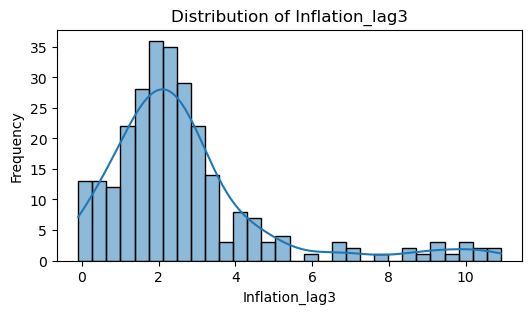

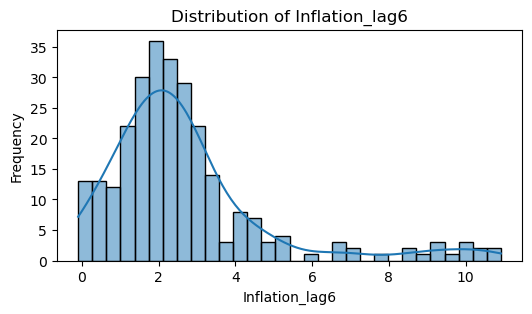

In [13]:
for col in df.columns:
    
    plt.figure(figsize=(6,3))
    
    sns.histplot(df[col], kde=True, bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

Inflation Spikes During Crisis Periods

In [16]:
df = df.reset_index()

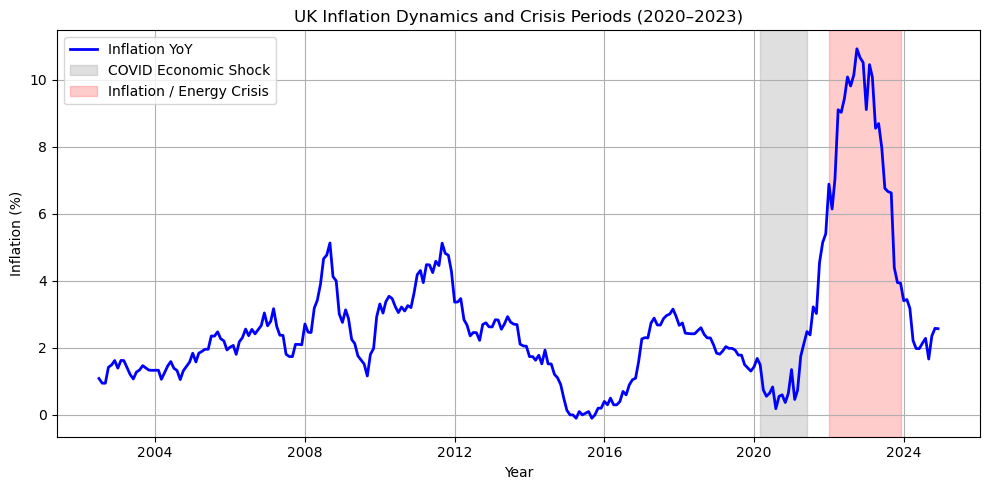

In [17]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

plt.figure(figsize=(10,5))

plt.plot(
    df.index,
    df["Inflation_YoY"],
    label="Inflation YoY",
    color="blue",
    linewidth=2
)

plt.axvspan(
    pd.to_datetime("2020-03-01"),
    pd.to_datetime("2021-06-01"),
    color="grey",
    alpha=0.25,
    label="COVID Economic Shock"
)

plt.axvspan(
    pd.to_datetime("2022-01-01"),
    pd.to_datetime("2023-12-01"),
    color="red",
    alpha=0.20,
    label="Inflation / Energy Crisis"
)

plt.title("UK Inflation Dynamics and Crisis Periods (2020–2023)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

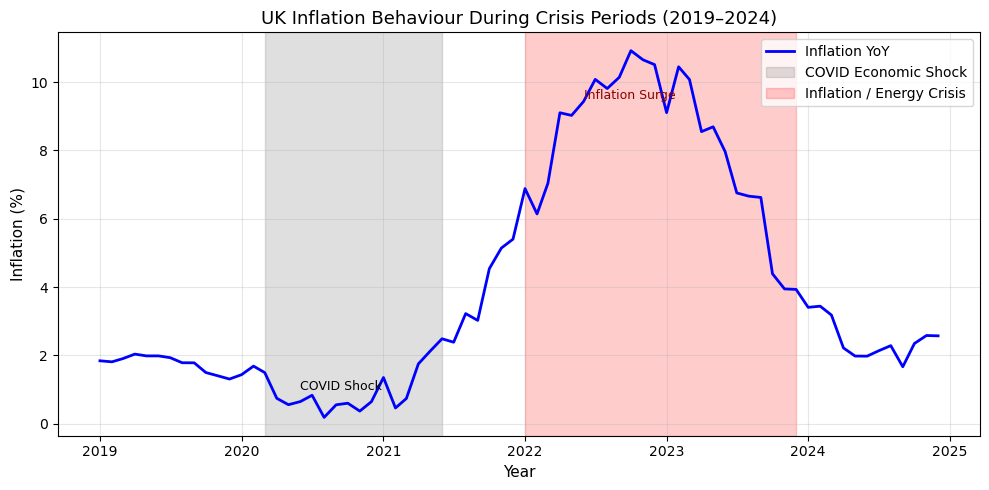

In [18]:
plt.figure(figsize=(10,5))

df_crisis = df[(df.index >= "2019-01-01") & (df.index <= "2024-12-31")]

plt.plot(
    df_crisis.index,
    df_crisis["Inflation_YoY"],
    label="Inflation YoY",
    color="blue",
    linewidth=2
)

plt.axvspan(
    pd.to_datetime("2020-03-01"),
    pd.to_datetime("2021-06-01"),
    color="grey",
    alpha=0.25,
    label="COVID Economic Shock"
)

plt.axvspan(
    pd.to_datetime("2022-01-01"),
    pd.to_datetime("2023-12-01"),
    color="red",
    alpha=0.2,
    label="Inflation / Energy Crisis"
)

plt.text(
    pd.to_datetime("2020-06-01"),
    1.0,
    "COVID Shock",
    fontsize=9,
    color="black"
)

plt.text(
    pd.to_datetime("2022-06-01"),
    9.5,
    "Inflation Surge",
    fontsize=9,
    color="darkred"
)

plt.legend()

plt.title("UK Inflation Behaviour During Crisis Periods (2019–2024)", fontsize=13)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Inflation (%)", fontsize=11)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lag Relationship Analysis

In [19]:
df["Inflation_lag3"] = df["Inflation_YoY"].shift(3)
df["Inflation_lag6"] = df["Inflation_YoY"].shift(6)

In [20]:
heatmap_vars = [
    "Inflation_YoY",
    "Inflation_lag3",
    "Inflation_lag6",
    "Unemployment",
    "Bank_Rate",
    "FTSE100"
]

In [21]:
df_heatmap = df[heatmap_vars].dropna()

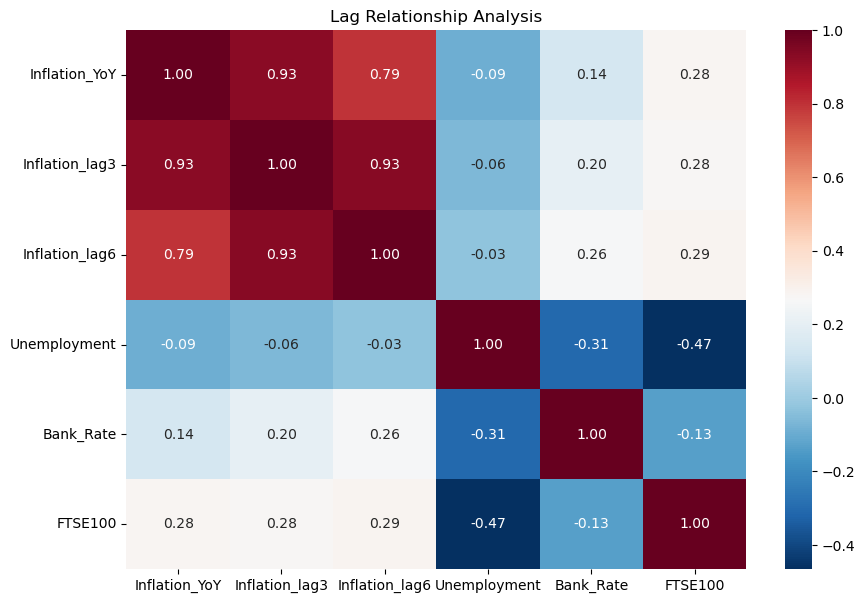

In [22]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap="RdBu_r",
    fmt=".2f"
)

plt.title("Lag Relationship Analysis")

plt.show()

In [23]:
print(df.head())
print(df.columns)

              CPI       GDP  Unemployment   RSI  Bank_Rate      FTSE100  \
Date                                                                      
2002-07-01  74.50  506386.0           5.2  78.5        4.0  4044.500000   
2002-08-01  74.60  506386.0           5.3  78.2        4.0  4227.299805   
2002-09-01  74.80  506386.0           5.2  78.6        4.0  3797.399902   
2002-10-01  74.95  509728.0           5.2  78.9        4.0  4039.699951   
2002-11-01  74.90  509728.0           5.1  79.5        4.0  4169.399902   

            Inflation_YoY  Inflation_lag3  Inflation_lag6  
Date                                                       
2002-07-01       1.085482             NaN             NaN  
2002-08-01       0.947226             NaN             NaN  
2002-09-01       0.944669             NaN             NaN  
2002-10-01       1.420839        1.085482             NaN  
2002-11-01       1.490515        0.947226             NaN  
Index(['CPI', 'GDP', 'Unemployment', 'RSI', 'Bank_Rate